# EDA: class-separating signals and dataset artifact audit

Two questions, answered in writing at the end:

1. Which forensic signal families plausibly separate authentic from
   manipulated content in this corpus?
2. Which apparent separations are dataset artifacts (resolution, format,
   JPEG quality, source composition) that a classifier would exploit as
   shortcuts?

Data discipline: this notebook reads train and validation only, through the
gated loader. The test split is frozen and unread.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from provenance_lens.data.access import load_split

RAW = Path("data/raw")
train = load_split("train")
val = load_split("val")
frame = pd.concat([train.assign(split="train"), val.assign(split="val")], ignore_index=True)
print(f"rows: {len(frame)} (train {len(train)}, val {len(val)})")
frame.groupby(["source", "label", "manipulation"]).size().rename("assets").to_frame()

rows: 102261 (train 84214, val 18047)


assets
source     label       manipulation        
cifake     authentic   none           49774
           manipulated ai_generated   50704
micc_f2000 authentic   none            1083
           manipulated copy_move        546
micc_f220  authentic   none              84
           manipulated copy_move         70

## Composition and the confound to keep in mind

Manipulation types are almost perfectly nested in sources: `ai_generated`
exists only in cifake and `copy_move` only in the MICC sources. Every
across-source comparison is therefore confounded by acquisition pipeline,
and honest signal separability must be judged within source.

In [2]:
frame["is_png"] = frame.path.str.lower().str.endswith(".png")
frame["pixels"] = frame.width * frame.height
frame["file_bytes"] = [ (RAW / p).stat().st_size for p in frame.path ]
summary = frame.groupby(["source", "label"]).agg(
    n=("sha256", "size"),
    width=("width", "median"),
    height=("height", "median"),
    png_share=("is_png", "mean"),
    median_bytes=("file_bytes", "median"),
)
summary

n   width  height  png_share  median_bytes
source     label                                                      
cifake     authentic    49774    32.0    32.0        1.0        2306.0
           manipulated  50704    32.0    32.0        1.0        2348.0
micc_f2000 authentic     1083  2048.0  1536.0        0.0     1924755.0
           manipulated    546  2048.0  1536.0        0.0     2029431.0
micc_f220  authentic       84   800.0   532.0        0.0       69100.5
           manipulated     70   800.0   532.0        0.0       70455.0

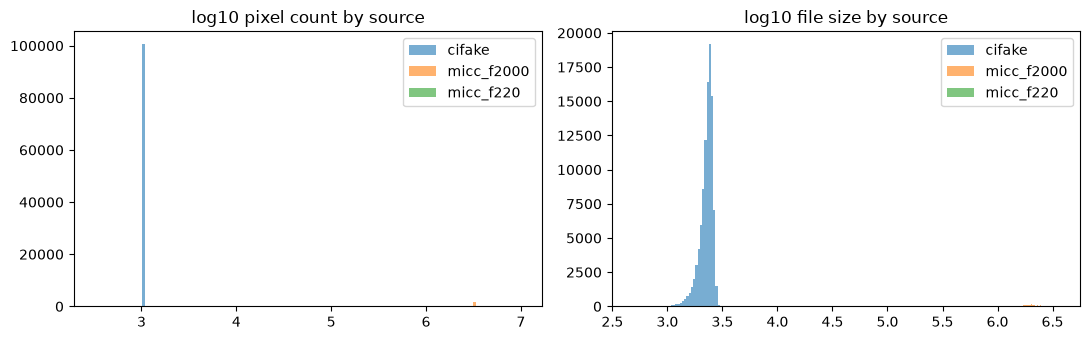

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for source, group in frame.groupby("source"):
    axes[0].hist(np.log10(group.pixels), bins=40, alpha=0.6, label=source)
    axes[1].hist(np.log10(group.file_bytes), bins=40, alpha=0.6, label=source)
axes[0].set_title("log10 pixel count by source")
axes[1].set_title("log10 file size by source")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## Trivial-feature audit: how far do artifacts alone go?

Rank AUC of features that carry no forensic content. Values near 1.0 mean a
classifier can solve the raw binary task without looking at manipulation
evidence at all.

In [4]:
def rank_auc(scores, labels):
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty(len(scores))
    ranks[order] = np.arange(1, len(scores) + 1)
    pos = labels.astype(bool)
    n_pos, n_neg = pos.sum(), (~pos).sum()
    return (ranks[pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

y = (frame.label == "manipulated").to_numpy()
audit = {}
for feature in ["pixels", "file_bytes", "is_png"]:
    auc = rank_auc(frame[feature].to_numpy(float), y)
    audit[feature] = round(max(auc, 1 - auc), 4)
print("global artifact AUCs (label from trivial features):", audit)

within = {}
for source, group in frame.groupby("source"):
    if group.label.nunique() < 2:
        continue
    ys = (group.label == "manipulated").to_numpy()
    within[source] = {
        f: round(max(rank_auc(group[f].to_numpy(float), ys),
                     1 - rank_auc(group[f].to_numpy(float), ys)), 4)
        for f in ["pixels", "file_bytes"]
    }
print("within-source artifact AUCs:", within)

global artifact AUCs (label from trivial features): {'pixels': np.float64(0.5054), 'file_bytes': np.float64(0.5317), 'is_png': np.float64(0.5055)}
within-source artifact AUCs: {'cifake': {'pixels': np.float64(0.5), 'file_bytes': np.float64(0.5385)}, 'micc_f2000': {'pixels': np.float64(0.5018), 'file_bytes': np.float64(0.6003)}, 'micc_f220': {'pixels': np.float64(0.5628), 'file_bytes': np.float64(0.5568)}}


## JPEG quality factor estimate (MICC only)

Approximated from the luminance quantization table scale against the
standard table. CIFAKE is PNG and has no quantization tables, which is
itself an artifact: format alone identifies the only source that contains
`ai_generated`.

In [5]:
STANDARD_LUMA = np.array([
    16,11,10,16,24,40,51,61,12,12,14,19,26,58,60,55,
    14,13,16,24,40,57,69,56,14,17,22,29,51,87,80,62,
    18,22,37,56,68,109,103,77,24,35,55,64,81,104,113,92,
    49,64,78,87,103,121,120,101,72,92,95,98,112,100,103,99,
], dtype=float)

def quality_estimate(path):
    try:
        with Image.open(path) as im:
            table = im.quantization and im.quantization.get(0)
        if not table:
            return np.nan
        scale = 100 * np.array(table, float) / STANDARD_LUMA
        mean_scale = float(np.mean(scale))
        return 50.0 / (mean_scale / 100) if mean_scale > 100 else 100 - mean_scale / 2
    except Exception:
        return np.nan

micc = frame[frame.source.str.startswith("micc")]
sample = micc.sample(min(600, len(micc)), random_state=0)
sample = sample.assign(qf=[quality_estimate(RAW / p) for p in sample.path])
sample.groupby(["source", "label"]).qf.describe()[["count", "mean", "std", "50%"]]

count       mean           std        50%
source     label                                                 
micc_f2000 authentic    375.0  98.502995  1.422984e-14  98.502995
           manipulated  179.0  98.502995  1.425072e-14  98.502995
micc_f220  authentic     28.0  74.746855  1.447163e-14  74.746855
           manipulated   18.0  74.746855  1.462285e-14  74.746855

## Pilot signals, judged within source

Cheap previews of two M2 families on a stratified sample: high-pass residual
energy (noise family) and 8-pixel blocking periodicity (compression family).
The question is only whether the within-source distributions differ enough
to justify the full extractors.

In [6]:
from scipy.ndimage import laplace


def load_gray(path, max_side=512):
    with Image.open(path) as im:
        im = im.convert("L")
        if max(im.size) > max_side:
            im.thumbnail((max_side, max_side))
        return np.asarray(im, float) / 255.0

def residual_energy(path):
    return float(np.mean(np.abs(laplace(load_gray(path)))))

def blocking_periodicity(path):
    g = load_gray(path)
    col_diff = np.abs(np.diff(g, axis=1)).mean(axis=0)
    if len(col_diff) < 16:
        return np.nan
    at_grid = col_diff[7::8].mean()
    off_grid = np.delete(col_diff, np.s_[7::8]).mean()
    return float(at_grid / (off_grid + 1e-9))

def stratified(group_frame, per_group, seed=0):
    parts = [
        g.sample(min(per_group, len(g)), random_state=seed)
        for _, g in group_frame.groupby(["source", "label"])
    ]
    return pd.concat(parts, ignore_index=True)

pilot = stratified(frame, per_group=300).copy()
pilot["residual"] = [residual_energy(RAW / p) for p in pilot.path]
pilot["blocking"] = [blocking_periodicity(RAW / p) for p in pilot.path]
pilot.groupby(["source", "label"])[["residual", "blocking"]].median()

residual  blocking
source     label                          
cifake     authentic    0.136252  1.154801
           manipulated  0.123009  1.107636
micc_f2000 authentic    0.051758  1.001023
           manipulated  0.063479  1.001686
micc_f220  authentic    0.064997  0.997864
           manipulated  0.070374  0.983951

within-source pilot-signal AUCs: {'cifake': {'residual': np.float64(0.5984), 'blocking': np.float64(0.5579)}, 'micc_f2000': {'residual': np.float64(0.5793), 'blocking': np.float64(0.5014)}, 'micc_f220': {'residual': np.float64(0.502), 'blocking': np.float64(0.6357)}}


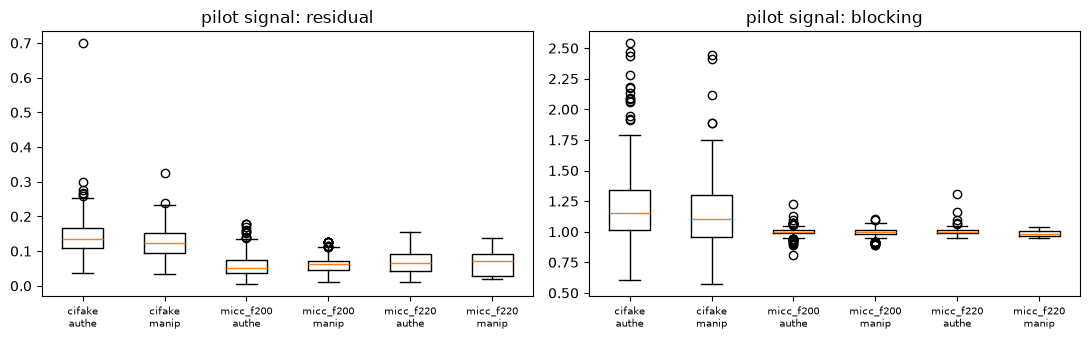

In [7]:
results = {}
for source, group in pilot.groupby("source"):
    if group.label.nunique() < 2:
        continue
    ys = (group.label == "manipulated").to_numpy()
    results[source] = {
        s: round(max(rank_auc(group[s].to_numpy(float), ys),
                     1 - rank_auc(group[s].to_numpy(float), ys)), 4)
        for s in ["residual", "blocking"]
    }
print("within-source pilot-signal AUCs:", results)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, signal in zip(axes, ["residual", "blocking"], strict=False):
    data, labels = [], []
    for (source, label), group in pilot.groupby(["source", "label"]):
        data.append(group[signal].dropna())
        labels.append(f"{source[:9]}\n{label[:5]}")
    ax.boxplot(data, tick_labels=labels)
    ax.set_title(f"pilot signal: {signal}")
    ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

## Findings

Written against the measured outputs above (train and validation, 102,261
assets; the test split was not read).

**Which signals plausibly separate the classes.**

1. High-pass residual energy is the strongest honest pilot signal: within
   cifake AUC 0.598 (n = 600) and within micc_f2000 AUC 0.579 (n = 600),
   with directions that differ by source (AI images have lower residual
   energy than CIFAR real images; copy-move JPEGs have slightly higher
   energy than their originals). This justifies the full M2 noise-residual
   family, including the per-region statistics the pilot lacks.
2. Blocking periodicity shows a weak global signal in cifake (0.558,
   plausibly Stable Diffusion upsampling structure surviving the PNG) and
   nothing in micc_f2000 (0.501). This is expected: copy-move moves a patch
   within one compression regime, so a global grid measure barely moves.
   The M2 compression family must be regional (grid misalignment between
   regions, ghost minima per region) or it will not earn its keep.
3. Copy-move manipulation barely shifts any global statistic (micc_f220
   pilot AUCs 0.502 and 0.636 on n = 154 are noise-dominated). The M2
   design consequence is clear: regional contrasts and seam scores over the
   3x3 grid, not whole-image scalars.

**Which correlations are dataset artifacts.**

1. File size predicts the label within every source: AUC 0.538 in cifake
   (median 2,348 versus 2,306 bytes), 0.600 in micc_f2000, 0.557 in
   micc_f220. Manipulated files are systematically slightly larger. Any
   model fed raw byte counts, or features that proxy them, can cheat; the
   M3 baseline therefore excludes file size and the M5 report should slice
   errors by file size to detect residual shortcut use.
2. JPEG quality factor is a pure source fingerprint: constant 98.5 across
   all of micc_f2000 and constant 74.7 across all of micc_f220, with zero
   within-source variance. It carries no manipulation signal here, and any
   quality-factor feature is really a source detector. It also explains the
   #21 observation that F220 assets are re-exports of F2000 content at a
   different quality.
3. Format and resolution separate sources perfectly (cifake is 100% PNG at
   32x32; MICC is 100% JPEG at 800x532 or 2048x1536) but do not solve the
   binary task globally (pixels AUC 0.505, is_png 0.506) because labels are
   balanced within the dominant source. The class-to-source nesting is
   total, however: ai_generated exists only in cifake and copy_move only in
   MICC, so per-type performance claims are really per-source claims, and
   the M5 breakdown must say so.

**Consequences carried forward.** M2 prioritizes noise residuals and
regional compression contrasts; the baseline feature set excludes file size
and quality factor; the copy_move stratum is small (700 assets corpus-wide),
so M5 per-type confidence intervals will be wide and the report must resist
overclaiming on that slice.